# Lab 10 Steganography
## Name - Manan Chahal
## Roll No - 23102C0044

In [26]:
import cv2 as cv
import matplotlib.pyplot as plt


# Importing the base image

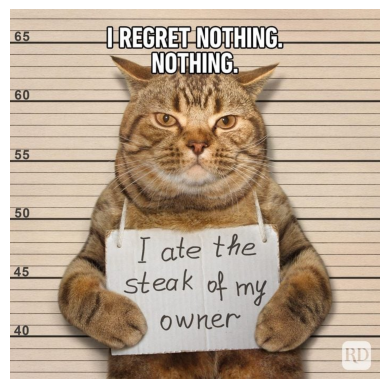

In [27]:
img = cv.imread('funny_cat.jpg')
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [28]:
print(type(img))
for what in img:
    print(what.shape)
    print(what)
    break

<class 'numpy.ndarray'>
(700, 3)
[[225 207 187]
 [227 209 189]
 [228 210 190]
 ...
 [221 197 173]
 [221 197 173]
 [221 197 173]]


# Image after setting all the MSBs to 1

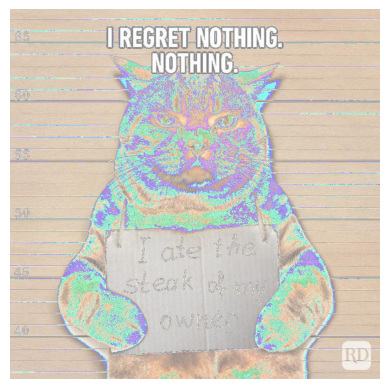

In [30]:
mod_img = img.copy()

for r in range(len(img)):
    for c in range(len(img[r])):
        mod_img[r][c] = 128 | img[r][c]

plt.imshow(mod_img)
plt.axis('off')
plt.show()

# Image After inverting all the MSBs

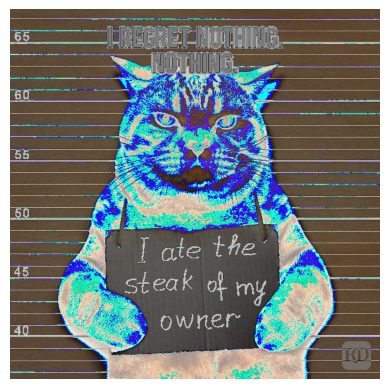

In [33]:
mod_img = img.copy()

for r in range(len(img)):
    for c in range(len(img[r])):
        mod_img[r][c] =  (img[r][c] ^ 128)

plt.imshow(mod_img)
plt.axis('off')
plt.show()

# Image after flipping all the LSBs

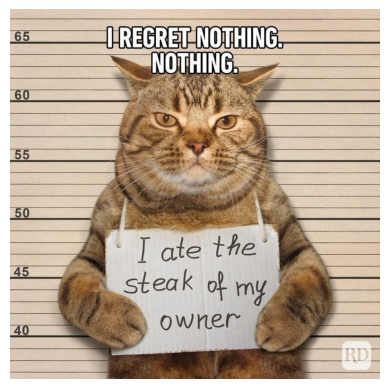

In [34]:
mod_img = img.copy()

for r in range(len(img)):
    for c in range(len(img[r])):
        mod_img[r][c] =  (img[r][c] ^ 1)

plt.imshow(mod_img)
plt.axis('off')
plt.show()

 Hence we can see that flipping even all the LSB of an image makes no noticiable diffrecne to the human eye,
 
 
hence, we can hide our message in those bits,

next we may define a function which will hide a string message into a an image after encoding it

In [107]:

STOP = "11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111"
STOPN = len(STOP)

def hide_in_img(img,text):

    bits = ''.join(f"{byte:08b}" for byte in text.encode('utf-8'))
    bits = bits + STOP


    if(len(bits) > (len(img)*len(img[0])*len(img[0][0]))):
        print('Hey this text is too big to fit')
        return None
    
    bitNo = 0
    n = len(bits)
    #print(bits[bitNo])
    
    mod_img = img.copy()

    for r in range(len(img)):
        for c in range(len(img[r])):
            for val in range(len(img[r][c])):
                if(bitNo >= n):
                    return mod_img
                else:
                    mod_img[r][c][val] = (img[r][c][val] & 254) | int(bits[bitNo])
                    bitNo+= 1


# Creating the Hidden Image

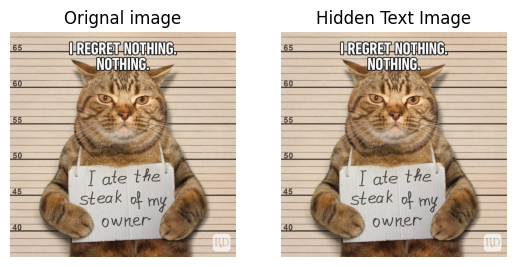

In [108]:
hidden_image = hide_in_img(img,"This is a hidden text in this image made using steganography by Manan Chahal 23102C0044")


plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Orignal image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hidden_image)
plt.title('Hidden Text Image')
plt.axis('off')

plt.show()

we can see that hiding the text made no visible diffrent,

now lets write a function to extract the hidden text

In [109]:
def bits_to_text(bits):
    text = "".join(chr(int(bits[i:i+8], 2)) for i in range(0, len(bits), 8))
    return text


def extract_hidden_text(img):
    bits = ""

    for r in range(len(img)):
        for c in range(len(img[r])):
            for val in range(len(img[r][c])):
                if(bits.endswith(STOP)):
                    return bits_to_text(bits[:-STOPN])
                bits = bits + str(img[r][c][val]&1)
    return "Error: No Hidden Text Found"

# Testing both images to verify the function and text extraction

In [110]:
extract_hidden_text(img)

'Error: No Hidden Text Found'

In [111]:
extract_hidden_text(hidden_image)

'This is a hidden text in this image made using steganography by Manan Chahal 23102C0044'

## Hence, We are able to properly extract the hidden text